# Diabetes Prediction using Neural Networks
### An end-to-end Artificial Neural Network (ANN) built with TensorFlow/Keras

**Dataset:** `diabetes.csv` - the Pima Indians Diabetes Dataset (768 patients, 8 medical
attributes, 1 binary target: Outcome).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

sns.set_style("whitegrid")
np.random.seed(42)
tf.random.set_seed(42)


I0000 00:00:1785817074.837230     485 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785817074.840697     485 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785817093.756267     485 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785817105.387158     485 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785817105.389832     485 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Part 1 — Data Preparation

In [2]:
df = pd.read_csv("diabetes.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Explore the dataset
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:\n", df.dtypes)
print("\nMissing values (literal NaNs):\n", df.isnull().sum())


Shape: (768, 9)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Missing values (literal NaNs):
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


**Observation:** `df.isnull().sum()` shows zero missing values for every column - but that's
misleading. This dataset has a well-known quirk: several medical measurements use `0` as a
placeholder for "not recorded," even though a value of 0 is biologically impossible for a living
patient (you can't have 0 blood pressure or 0 BMI). Let's check for this before trusting the data.


In [4]:
# Investigate hidden missing values encoded as 0
zero_check_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for c in zero_check_cols:
    zero_count = (df[c] == 0).sum()
    print(f"{c}: {zero_count} zero values ({zero_count/len(df)*100:.1f}%)")


Glucose: 5 zero values (0.7%)
BloodPressure: 35 zero values (4.6%)
SkinThickness: 227 zero values (29.6%)
Insulin: 374 zero values (48.7%)
BMI: 11 zero values (1.4%)


**Cleaning decision:** `Insulin` (48.7% zeros) and `SkinThickness` (29.6% zeros) have far too
many "missing" values to drop those rows - that would throw away nearly half the dataset. Instead,
we replace the 0s in these medically-implausible columns with the **median** of the real
(non-zero) values in that column. The median is used instead of the mean because it's less
sensitive to outliers in skewed medical data.


In [5]:
df_clean = df.copy()
for c in zero_check_cols:
    median_value = df_clean.loc[df_clean[c] != 0, c].median()
    df_clean[c] = df_clean[c].replace(0, median_value)

# Confirm the fix
for c in zero_check_cols:
    print(f"{c}: {(df_clean[c] == 0).sum()} zero values remaining")


Glucose: 0 zero values remaining
BloodPressure: 0 zero values remaining
SkinThickness: 0 zero values remaining
Insulin: 0 zero values remaining
BMI: 0 zero values remaining


In [6]:
# Check the target variable balance
df_clean["Outcome"].value_counts()


Outcome
0    500
1    268
Name: count, dtype: int64

**Observation:** The target is moderately imbalanced - 500 patients without diabetes (0) vs
268 with diabetes (1), roughly a 65/35 split. This isn't extreme, but it's worth keeping in mind
when interpreting accuracy later (a model that just guesses "no diabetes" every time would already
be ~65% accurate without learning anything).


In [7]:
# Basic statistics after cleaning
df_clean.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
# 3. Separate features (X) and target (y)
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (768, 8)
y shape: (768,)


In [9]:
# 4. Train-test split (80% train, 20% test), stratified to preserve the class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (614, 8)
Test set: (154, 8)


In [10]:
# 5. Feature scaling - neural networks train much better when input features are on a
# similar scale (e.g. Glucose ranges 0-200 while DiabetesPedigreeFunction ranges 0-2.5).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # use the SAME scaler fit on training data only

print("Mean of scaled training features (should be ~0):", X_train_scaled.mean(axis=0).round(2))
print("Std of scaled training features (should be ~1):", X_train_scaled.std(axis=0).round(2))


Mean of scaled training features (should be ~0): [-0. -0.  0. -0. -0. -0. -0. -0.]
Std of scaled training features (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


### Part 1 — Deliverables Summary

- **Dataset summary:** 768 patients, 8 features + 1 target column. No literal NaNs, but 5 columns
  contained biologically-impossible zeros treated as hidden missing values and imputed with the
  column median.
- **Feature/target separation:** X has 8 medical attributes; y is the binary `Outcome`.
- **Scaled datasets:** `X_train_scaled` and `X_test_scaled` - both standardized (mean 0, std 1)
  using a scaler fit only on the training set, to avoid leaking test-set information into training.


## Part 2 — Building the Artificial Neural Network

In [11]:
# Build a Sequential ANN: Input -> Hidden Layer 1 -> Hidden Layer 2 -> Output
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),        # Input layer: 8 features
    Dense(16, activation="relu"),                     # First hidden layer
    Dense(8, activation="relu"),                       # Second hidden layer
    Dense(1, activation="sigmoid")                     # Output layer: binary classification
])

model.summary()


E0000 00:00:1785817108.087264     485 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

**Architecture explanation:**

- **Input layer:** 8 neurons - one per feature (Pregnancies, Glucose, BloodPressure,
  SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age).
- **First hidden layer:** 16 neurons with **ReLU** activation. ReLU (`max(0, x)`) is the standard
  choice for hidden layers - it's computationally simple and helps the network learn non-linear
  patterns without the "vanishing gradient" problems older activations (like sigmoid) have in deep
  layers.
- **Second hidden layer:** 8 neurons, also ReLU. Narrowing the layer size (16 -> 8) is a common
  pattern that lets the network progressively compress what it's learned toward the final decision.
- **Output layer:** 1 neuron with **Sigmoid** activation. Sigmoid squashes the output into a 0-1
  range, which we interpret as "probability of diabetes" - exactly what's needed for binary
  classification.


In [12]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


**Compilation choices:**

- **Optimizer: Adam** - an adaptive learning-rate optimizer that generally converges faster and
  more reliably than plain gradient descent, making it a strong default for most ANN problems.
- **Loss: Binary Crossentropy** - the standard loss function for binary (0/1) classification
  problems; it penalizes confident wrong predictions more heavily than uncertain ones.
- **Metric: Accuracy** - tracked during training so we can monitor how often the model's
  predictions match the true labels.


## Part 3 — Model Training

In [13]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=2
)


Epoch 1/100


31/31 - 3s - 90ms/step - accuracy: 0.3666 - loss: 0.7294 - val_accuracy: 0.4959 - val_loss: 0.7160


Epoch 2/100


31/31 - 1s - 24ms/step - accuracy: 0.5397 - loss: 0.6912 - val_accuracy: 0.6179 - val_loss: 0.6798


Epoch 3/100


...

31/31 - 0s - 6ms/step - accuracy: 0.8228 - loss: 0.3734 - val_accuracy: 0.7805 - val_loss: 0.4620


Epoch 99/100


31/31 - 0s - 5ms/step - accuracy: 0.8208 - loss: 0.3728 - val_accuracy: 0.7886 - val_loss: 0.4622


Epoch 100/100


31/31 - 0s - 5ms/step - accuracy: 0.8248 - loss: 0.3722 - val_accuracy: 0.7886 - val_loss: 0.4632


**Epoch choice:** 100 epochs with a batch size of 16 was used, holding back 20% of the
training data as a validation set to monitor for overfitting during training (i.e. checking
whether the model starts memorizing the training data instead of generalizing).


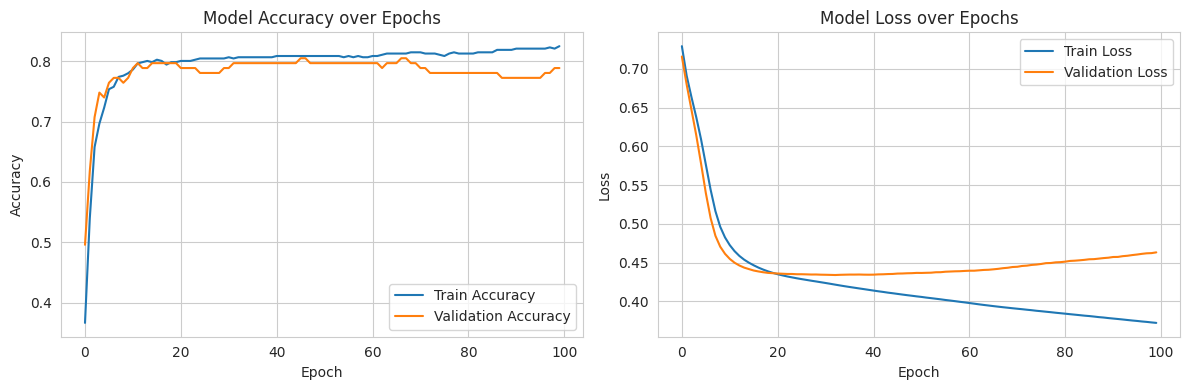

In [14]:
# Plot training vs validation accuracy and loss over epochs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Model Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Validation Loss")
axes[1].set_title("Model Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig("charts/training_history.png")
plt.show()


In [15]:
final_train_acc = history.history["accuracy"][-1]
final_val_acc = history.history["val_accuracy"][-1]
print(f"Final training accuracy: {final_train_acc:.4f}")
print(f"Final validation accuracy: {final_val_acc:.4f}")


Final training accuracy: 0.8248
Final validation accuracy: 0.7886


### Part 3 — Deliverables Summary

- **Training output:** accuracy/loss curves plotted above, showing how the model improved across
  100 epochs.
- **Final training accuracy:** printed above.
- **Epochs used:** 100, with batch size 16 and a 20% validation split.


## Part 4 — Model Evaluation

In [16]:
# 1. Generate predictions (probabilities) on the test set
y_pred_proba = model.predict(X_test_scaled, verbose=0)

# 2. Convert probabilities into binary class labels using a 0.5 threshold
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

y_pred[:10]  # preview first 10 predictions


array([1, 0, 0, 1, 0, 0, 0, 1, 0, 1])

In [17]:
# 3a. Accuracy Score
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Accuracy: 0.7532


Confusion Matrix:
 [[83 17]
 [21 33]]


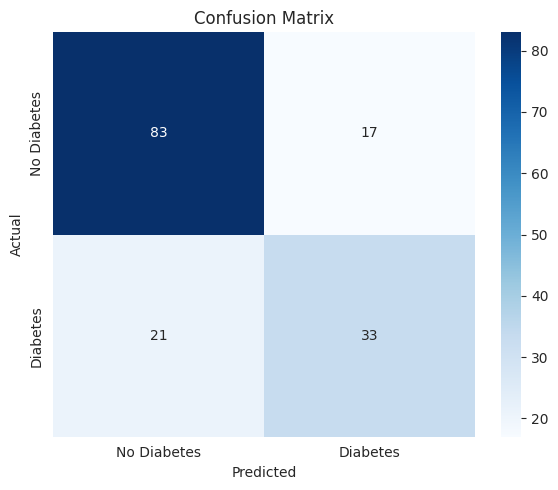

In [18]:
# 3b. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("charts/confusion_matrix.png")
plt.show()


In [19]:
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))


              precision    recall  f1-score   support

 No Diabetes       0.80      0.83      0.81       100
    Diabetes       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



### Part 4 — Interpretation

The confusion matrix breaks predictions into four groups:
- **True Negatives** (top-left): correctly predicted "No Diabetes"
- **False Positives** (top-right): predicted "Diabetes" but patient didn't have it
- **False Negatives** (bottom-left): predicted "No Diabetes" but patient actually had it - the
  riskiest kind of error in a medical context, since a missed diagnosis delays treatment
- **True Positives** (bottom-right): correctly predicted "Diabetes"

Given the class imbalance (65% No Diabetes / 35% Diabetes) noted in Part 1, accuracy alone can be
a bit misleading - a model could reach ~65% accuracy just by always predicting "No Diabetes."
That's why the confusion matrix and classification report (precision/recall per class) matter more
here than accuracy alone: they reveal whether the model is actually learning to detect the
minority "Diabetes" class, or just leaning on the majority class to look good on paper.
